In [8]:
import pandas as pd 
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from matplotlib.markers import MarkerStyle
import seaborn as sns 
import pickle 
from sklearn import metrics 
import sys 
import scipy.stats
import glob
import time 
import json
from sklearn.metrics import auc, roc_curve, roc_auc_score

from config import (llm_review_path, home_path, supp_table_path, figure_path_2)

sys.path.insert(1, home_path)
from common_functions import sort_dict_by_value,format_p, mean_confidence_interval, entropy, sort_dict_by_key, my_colors

In [9]:
def p_val_to_stars(p):
    if p <= 0.001:
        return "***"
    if p <= 0.01:
        return "**"
    if p <= 0.05:
        return "*"
    return "ns"

def save_figure(fig, name, root_path = figure_path_2, save_svg = True):
    fig.savefig(root_path + name + ".png", bbox_inches = "tight")
    if save_svg:
        fig.savefig(root_path + name + ".svg", format="svg", dpi = 1200, bbox_inches = "tight")

In [10]:
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']

def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df

In [11]:

model_info = pd.read_csv("model_info.txt", delimiter = "\t")

model_info["shorthand_name"] = [
    "esm_1_43M",
    "esm_1_85M",
    "esm_1b",
    "esm_1_UR100",
    "esm_1_UR50D",
    "esm_1_UR50",
    "esm_1v",
    "esm_2",
    "esm_2_150M",
    "esm_2_15B",
    "esm_2_35M",
    "esm_2_650M",
    "esm_2_8M",
    "protbert",
    "protbert_bfd"
]

model_to_my_string = {
    "ESM 1 43M": "esm_1_43M",
    "ESM 1 85M": "esm_1_85M",
    "ESM 1 UR100": "esm_1_UR100",
    "ESM 1 UR50": "esm_1_UR50",
    "ESM 1 UR50D": "esm_1_UR50D",
    "ESM 1b": "esm_1b",
    "ESM 1v": "esm_1v",
    "ESM 2 150M": "esm_2_150M",
    "ESM 2 15B":"esm_2_15B",
    "ESM 2 35M":"esm_2_35M",
    "ESM 2 3B":"esm_2",
    "ESM 2 650M":"esm_2_650M",
    "ESM 2 8M":"esm_2_8M",
    "protbert":"protbert"
}

model_to_base_string = dict(zip(model_info["shorthand_name"].values, model_info["base_string"].values))
model_to_params_string = dict(zip(model_info["shorthand_name"].values, model_info["params_string"].values))
model_to_dataset_string = dict(zip(model_info["shorthand_name"].values, model_info["dataset_string"].values))
model_to_model_identifier = dict(zip(model_info["shorthand_name"].values, model_info["model_string"].values))



ur_50_models = ["esm_1_43M", "esm_1_85M", "esm_1_UR50", "esm_1_UR50D", "esm_1b", "esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]
ur_100_models = ["esm_1_UR100", "protbert"]
ur_90_models = ["esm_1v"]

model_to_color = {}
ur_50_color = "#A3320B"
ur_90_color =  "#2E8B57" # seagreen
ur_100_color =  "#1E90FF" # "dodgerblue" 

for m in ur_50_models : model_to_color[m] = ur_50_color
for m in ur_100_models : model_to_color[m] = ur_100_color
for m in ur_90_models : model_to_color[m] = ur_90_color

In [12]:
biolip_cleaned = pd.read_csv(llm_review_path + "data/biolip/biolip_cleaned.csv.gz")
biolip_cleaned["identifier"] = biolip_cleaned["PDB_ID"] + "_" + biolip_cleaned["Receptor_chain"]

len(biolip_cleaned)

537

In [13]:
biolip_header = [
    "PDB ID",
    "Receptor chain",
    "Resolution",
    "Binding site number code",
    "Ligand ID CCD",
    "Ligand chain",
    "Ligand serial number",
    "Binding site residues (with PDB residue numbering)",
    "Binding site residues (with residue re-numbered starting from 1)",
    "Catalytic site residues with PDB residue numbering",
    "Catalytic site residues with residue re-numbered starting from 1",
    "EC number",
    "GO terms",
    "Binding affinity by manual survey of the original literature. The information in '()' is the PubMed ID",
    "Binding affinity provided by the Binding MOAD database. The information in '()' is the ligand information in Binding MOAD",
    "Binding affinity provided by the PDBbind-CN database. The information in '()' is the ligand information in PDBbind-CN",
    "Binding affinity provided by the BindingDB database",
    "UniProt ID",
    "PubMed ID",
    "Residue sequence number of the ligand (field _atom_site.auth_seq_id in PDBx/mmCIF format)",
    "Receptor sequence",
] # from the biolip documentation

biolip_raw = pd.read_csv(llm_review_path + "data/biolip/BioLiP.txt", delimiter = "\t", names = biolip_header)
biolip_raw["identifier"] = biolip_raw["PDB ID"] + "_" + biolip_raw["Receptor chain"]


biolip_cleaned = pd.read_csv(llm_review_path + "data/biolip/biolip_cleaned.csv.gz")
biolip_cleaned["identifier"] = biolip_cleaned["PDB_ID"] + "_" + biolip_cleaned["Receptor_chain"]

biolip_cleaned["num_cat_sites"] = biolip_cleaned["Catalytic_site_residues_numbered"].apply(
    lambda x : len(x.split(" "))
)

biolip_cleaned["length"] = biolip_cleaned["Receptor_sequence"].apply(lambda x : len(x))

biolip_cleaned["cat_site_ratio"] = biolip_cleaned["num_cat_sites"] / biolip_cleaned["length"] 

id_to_num_cat_sites = dict(zip(biolip_cleaned["identifier"].values, biolip_cleaned["num_cat_sites"].values))
id_to_cat_site_ratio = dict(zip(biolip_cleaned["identifier"].values, biolip_cleaned["cat_site_ratio"].values))

/tmp/ipykernel_125371/281865558.py:25: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  biolip_raw = pd.read_csv(llm_review_path + "data/biolip/BioLiP.txt", delimiter = "\t", names = biolip_header)


In [14]:
biolip_mask_res_path = llm_review_path + "masked_results/biolip/"

model_list = [
    "esm_1_43M",
    "esm_1_85M",
    "esm_1_UR50",
    "esm_1_UR50D",
    "esm_1_UR100",
    "esm_1b",  
    "esm_1v",  
    "esm_2_150M",  
    "esm_2_15B",  
    "esm_2_35M",  
    "esm_2",  
    "esm_2_650M",  
    "esm_2_8M",  
    "protbert"
]



In [15]:
with open(home_path + "singh/nlp_review/isabel/biolip_cleaned_site_entropy_vals.pkl", "rb") as f:
    model_site_entropy_lists = pickle.load(f)
f.close()

auroc_res = {m : {} for m in model_list}

for index, row in biolip_cleaned.iterrows():
    seq = [*row["Receptor_sequence"]]
    ident = row["identifier"]
    cat_sites = row["Catalytic_site_residues_numbered"].split(" ")
    cat_site_ref = []
    cat_site_pos = []
    for cs in cat_sites:
        ref = cs[0]
        pos = int(cs[1:])
        cat_site_ref.append(ref)
        cat_site_pos.append(pos)
        assert seq[pos - 1] == ref
    
    labels = np.zeros(len(seq))
    for cs_pos in cat_site_pos:
        labels[cs_pos - 1] = 1
        
    for m in model_list:
 
        predictions = list(sort_dict_by_key(model_site_entropy_lists[m][ident]).values())
        # order of entropy - more negative needs to correspond to more likely catalytic site
        # need to make 'positive' class 0 to line up correctly 
        fpr, tpr, thresholds = metrics.roc_curve(labels, predictions, pos_label=0)
        auroc = metrics.auc(fpr, tpr)
#         m = "esm_2"
        auroc_res[m][ident] = auroc
        

In [16]:
with open(home_path + "singh/nlp_review/isabel/biolip_cleaned_site_entropy_vals.pkl", "rb") as f:
    model_site_entropy_lists = pickle.load(f)
f.close()

average_entropy_res = {m : {} for m in model_list}

for index, row in biolip_cleaned.iterrows():
    ident = row["identifier"]
    for m in model_list:
        ent_vals = list(sort_dict_by_key(model_site_entropy_lists[m][ident]).values())
        mean_entropy = np.mean(ent_vals)
        average_entropy_res[m][ident] = mean_entropy
        
average_entropy_df = pd.DataFrame(average_entropy_res)

average_entropy_df

,esm_1_43M,esm_1_85M,esm_1_UR50,esm_1_UR50D,esm_1_UR100,esm_1b,esm_1v,esm_2_150M,esm_2_15B,esm_2_35M,esm_2,esm_2_650M,esm_2_8M,protbert
7pcy_A,3.286208,3.115315,2.361153,2.464054,2.730706,1.956024,1.956065,2.600143,0.779662,2.906842,1.040581,1.616328,3.284771,2.226975
1bxo_A,3.082020,2.363561,1.428396,1.419061,1.703733,1.301806,1.869113,1.921231,1.125848,2.572257,1.214626,1.373633,3.366876,1.421804
3eng_A,4.054466,4.002283,1.701797,1.656165,2.283511,1.508508,1.889803,1.999794,1.110694,3.919411,1.194362,1.424783,4.104386,1.417352
1isv_B,2.681906,1.932735,0.963680,0.998579,0.510476,0.889263,0.697531,1.797133,0.518612,2.274631,0.739015,1.214200,3.115648,0.422652
1pla_A,3.002783,2.829403,1.980780,2.163271,2.301244,1.716194,1.745147,2.346853,0.741258,2.739530,1.086733,1.464336,3.112316,1.548658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2qes_A,4.085145,4.086485,4.058009,4.017269,4.064996,4.051781,4.078338,4.041318,1.803693,4.089614,3.007103,4.044791,4.065818,4.057462
1elt_A,2.482631,2.242556,1.265815,1.390341,1.250726,1.192825,1.883403,2.101946,1.098163,2.412633,1.219926,1.433384,2.791659,1.081932
1zbk_A,2.617033,2.135159,1.730203,1.877412,1.221542,1.601232,2.159127,2.091530,1.603197,2.395507,1.714357,1.794601,3.291663,0.699348
5tj9_C,3.724726,2.847042,1.972860,2.012195,2.161552,1.918334,2.159419,3.633035,2.245731,3.816457,2.621164,2.745802,3.748354,1.674754


In [17]:
summary_df_1 = pd.DataFrame(auroc_res)

In [18]:
model_to_mean_auroc = {}
model_to_median_auroc = {}
for k, v in auroc_res.items():
    model_to_mean_auroc[k] = np.mean(list(v.values()))
    model_to_median_auroc[k] = np.median(list(v.values()))
    
model_to_mean_auroc = sort_dict_by_value(model_to_mean_auroc, reverse = True)
model_to_median_auroc = sort_dict_by_value(model_to_median_auroc, reverse = True)

model_to_mean_auroc

{'esm_1v': 0.9024455413543621,
 'esm_2': 0.9019031159060141,
 'esm_1b': 0.9017807257526896,
 'esm_2_650M': 0.8957051276982545,
 'esm_2_15B': 0.8946725438606433,
 'esm_1_UR50': 0.8946662122053948,
 'esm_1_UR50D': 0.8940705027912225,
 'protbert': 0.8731532227234442,
 'esm_1_UR100': 0.8680327731611912,
 'esm_1_85M': 0.8526621543956194,
 'esm_2_150M': 0.8487706170253922,
 'esm_2_35M': 0.7878042963848666,
 'esm_1_43M': 0.7698305424234954,
 'esm_2_8M': 0.5981400713577231}

/tmp/ipykernel_125371/3124033058.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_labels, rotation = 90)
/tmp/ipykernel_125371/3124033058.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


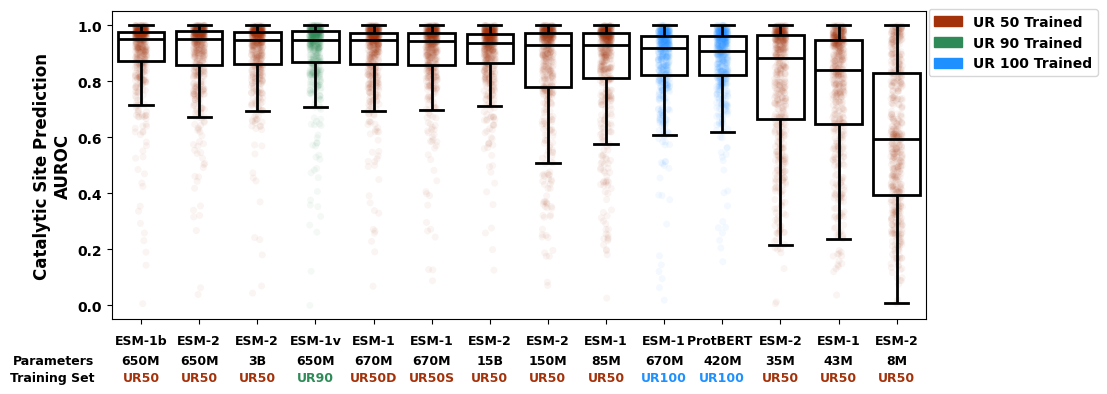

In [19]:
fig, ax = plt.subplots(figsize = (10.5, 4))

data = []
x_labels = []
x = []
my_pal = {}

bases = []
params = []
datasets = []



for c, (k, v) in enumerate(model_to_median_auroc.items()):
  
    
    x.append(c)
    data.append(list(summary_df_1[k].values))
    
    if k == "esm_2_3B":
        k = "esm_2"
    
    x_labels.append(k)
    my_pal[c] = model_to_color[k]
    bases.append(model_to_base_string[k])
    params.append(model_to_params_string[k])
    datasets.append(model_to_dataset_string[k])


sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.05,
    palette = my_pal,
    ax= ax
)

ax.set_xticklabels(x_labels, rotation = 90)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels("")
for model_base, x_val in zip(bases, x):
    ax.text(x_val, -0.14, model_base, horizontalalignment = "center", fontweight = "bold", fontsize = 9)
    ax.text(x_val, -0.21, params[x_val], horizontalalignment = "center", fontweight = "bold", fontsize = 9)
    ax.text(x_val, -0.27, datasets[x_val].replace("-", "").replace(" ", ""), color = my_pal[x_val], fontweight = "bold", horizontalalignment = "center", fontsize = 9)
    
ax.text(-0.8, -0.21, "Parameters", horizontalalignment = "right", fontsize = 9, fontweight = "bold")
ax.text(-0.8, -0.27, "Training Set", horizontalalignment = "right", fontsize = 9, fontweight = "bold" )
ax.set_ylabel("Catalytic Site Prediction\nAUROC", fontsize = 12, fontweight = "bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')

ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.72,0.53,0.5,0.5), prop = {"weight" : "bold"})


save_figure(fig, "cat_site_14_model_boxplot")

In [20]:
v1 = summary_df_1["esm_2_650M"].to_dict()

predictions = list(sort_dict_by_key(model_site_entropy_lists["esm_2_650M"]["5tj9_C"]).values())

summary_stats = []
for index, row in biolip_cleaned.iterrows():
    ident = row["identifier"]
#     row = biolip_cleaned.loc[biolip_cleaned["identifier"] == "5tj9_C"].iloc[0]
    cat_sites = row["Catalytic_site_residues_numbered"].split(" ")
    seq = [*row["Receptor_sequence"]]
    cat_site_ref = []
    cat_site_pos = []
    for cs in cat_sites:
        ref = cs[0]
        pos = int(cs[1:])
        cat_site_ref.append(ref)
        cat_site_pos.append(pos)
        assert seq[pos - 1] == ref

    labels = np.zeros(len(seq))
    for cs_pos in cat_site_pos:
        labels[cs_pos - 1] = 1
    summary_stats.append([np.sum(labels), len(labels),ident, v1[ident]])
    
summary_stats = pd.DataFrame(summary_stats, columns = ["cat sites", "length", "entry", "auroc"])
# summary_stats.sort_values(by = "cat sites", ascending = False).head(40)

428 428
Unnamed: 0                                                                        444
Catalytic_site_residues_numbered    C191 D108 D153 E155 E182 E285 H180 H193 Q308 R...
PDB_ID                                                                           6c4a
Receptor_chain                                                                      B
Receptor_sequence                   MSVVGTPKSAEQIQQEWDTNPRWKDVTRTYSAEDVVALQGSVVEEH...
UniProt ID                                                                     P9WKK7
identifier                                                                     6c4a_B
num_cat_sites                                                                      13
length                                                                            428
cat_site_ratio                                                               0.030374
Name: 443, dtype: object


/tmp/ipykernel_125371/342856103.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
/tmp/ipykernel_125371/342856103.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


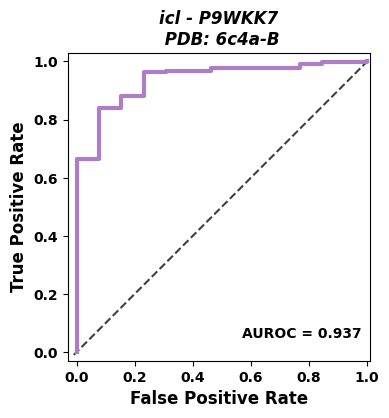

In [21]:
m = "esm_2_650M"

my_val = "6c4a_B"

row = biolip_cleaned.loc[biolip_cleaned["identifier"] == my_val].iloc[0]
cat_sites = row["Catalytic_site_residues_numbered"].split(" ")
seq = [*row["Receptor_sequence"]]
cat_site_ref = []
cat_site_pos = []
for cs in cat_sites:
    ref = cs[0]
    pos = int(cs[1:])
    cat_site_ref.append(ref)
    cat_site_pos.append(pos)
    assert seq[pos - 1] == ref

labels = np.zeros(len(seq))
for cs_pos in cat_site_pos:
    labels[cs_pos - 1] = 1

predictions = list(sort_dict_by_key(model_site_entropy_lists[m][my_val]).values())


print(len(predictions), len(labels))

fig, ax = plt.subplots(figsize = (4,4))
fpr, tpr, thresholds = metrics.roc_curve(labels, predictions, pos_label=0)
auroc = metrics.auc(fpr, tpr)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]) - 0.01,  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]) + 0.01,  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, '--', alpha=0.75, zorder=0, color = "black")
ax.set_aspect('equal')


ax.plot(fpr, tpr, color = "#ae7dc7", linewidth = 3)

ax.set_xlim(right = 1.01, left= -0.03)
ax.set_ylim(top = 1.03, bottom = -0.03)

ax.set_xlabel("False Positive Rate", fontsize = 12, fontweight = "bold")
ax.set_ylabel("True Positive Rate", fontsize = 12, fontweight = "bold")
ax.text(0.57,0.05,"AUROC = " + str(round(auroc, 3)), fontweight = "bold")

ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
# ax.set_title("")
print(row)
ax.set_title("icl - P9WKK7\n PDB: " + my_val.split("_")[0] + "-" + my_val.split("_")[1], fontsize = 12, fontstyle = "italic", fontweight = "bold")

save_figure(fig, "auroc_cat_site_6c4a-B")

In [22]:
df = pd.read_csv(llm_review_path + "data/biolip/blast_cleaned_biolip_avg_entropy_homologs.csv.gz")
df["identifier"] = df["PDB ID"] + "_" + df["Receptor chain"]

df = df.loc[
    (df["identifier"].isin(summary_df_1.index)) 
]

In [23]:
df = pd.read_csv(llm_review_path + "data/biolip/blast_cleaned_biolip_avg_entropy_homologs.csv.gz")
df["identifier"] = df["PDB ID"] + "_" + df["Receptor chain"]

df = df.loc[
    (df["identifier"].isin(summary_df_1.index)) 
]


df_s1 = df.loc[df["dataset"] == "UniRef50"]
df_s2 = df.loc[df["dataset"] == "UniRef100"]
df_s3 = df.loc[df["dataset"] == "UniRef90"]

ur_50_ident_to_homologs = dict(zip(df_s1["identifier"].values, df_s1["homologs"].values))
ur_100_ident_to_homologs = dict(zip(df_s2["identifier"].values, df_s2["homologs"].values))
ur_90_ident_to_homologs = dict(zip(df_s3["identifier"].values, df_s3["homologs"].values))

ds_to_homs = {
    "UR50" : ur_50_ident_to_homologs, 
    "UR90" : ur_90_ident_to_homologs,
    "UR100" : ur_100_ident_to_homologs,
} 

group_to_color = {
    "UR50" : "maroon",
    "UR100" : "darkcyan", 
    "UR90" : "forestgreen"
}




In [24]:
y_vals = []
p_vals = []
ds_similarity = []

groups = ["UR50 UR100", "UR90 UR100",  "UR50 UR90",]

m1 = "esm_1_UR50"
m2 = "esm_1_UR100"

col_a = summary_df_1[[m1, m2]]
col_a["ur_50_homs"] = ur_50_ident_to_homologs
col_a["ur_100_homs"] = ur_100_ident_to_homologs
col_a["ur_50_better"] = col_a[m1] >  col_a[m2]
col_a["hom_diff"] = col_a["ur_100_homs"] - col_a["ur_50_homs"]
col_a["performance_diff"] = col_a[m2] - col_a[m1]

corr,p = scipy.stats.spearmanr(col_a["performance_diff"], col_a["hom_diff"])
print(corr, p)
y_vals.append(corr)
p_vals.append(p)

corr_ds, p_ds =  scipy.stats.spearmanr(col_a["ur_50_homs"], col_a["ur_100_homs"])
ds_similarity.append(corr_ds)


m1 = "esm_1v"
m2 = "esm_1_UR100"

col_a = summary_df_1[[m1, m2]]
col_a["ur_90_homs"] = ur_90_ident_to_homologs
col_a["ur_100_homs"] = ur_100_ident_to_homologs
col_a["ur_90_better"] = col_a[m1] >  col_a[m2]
col_a["hom_diff"] = col_a["ur_100_homs"] - col_a["ur_90_homs"]
col_a["performance_diff"] = col_a[m2] - col_a[m1]

corr,p = scipy.stats.spearmanr(col_a["performance_diff"], col_a["hom_diff"])
print(corr, p)
y_vals.append(corr)
p_vals.append(p)

corr_ds, p_ds =  scipy.stats.spearmanr(col_a["ur_100_homs"], col_a["ur_90_homs"])
ds_similarity.append(corr_ds)


m1 = "esm_1b"
m2 = "esm_1v"

col_a = summary_df_1[[m1, m2]]
col_a["ur_50_homs"] = ur_50_ident_to_homologs
col_a["ur_90_homs"] = ur_90_ident_to_homologs
col_a["ur_50_better"] = col_a[m1] >  col_a[m2]
col_a["hom_diff"] = col_a["ur_90_homs"] - col_a["ur_50_homs"]
col_a["performance_diff"] = col_a[m2] - col_a[m1]

corr,p = scipy.stats.spearmanr(col_a["performance_diff"], col_a["hom_diff"])
y_vals.append(corr)
p_vals.append(p)

corr_ds, p_ds =  scipy.stats.spearmanr(col_a["ur_50_homs"], col_a["ur_90_homs"])
ds_similarity.append(corr_ds)


0.11437230245398869 0.00798003132196607
0.09754553850703435 0.023785647436392297


/tmp/ipykernel_125371/2000433668.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([""])


[Text(0, 0.0, '0.00'),
 Text(0, 0.04, '0.04'),
 Text(0, 0.08, '0.08'),
 Text(0, 0.12, '0.12'),
 Text(0, 0.16, '0.16')]

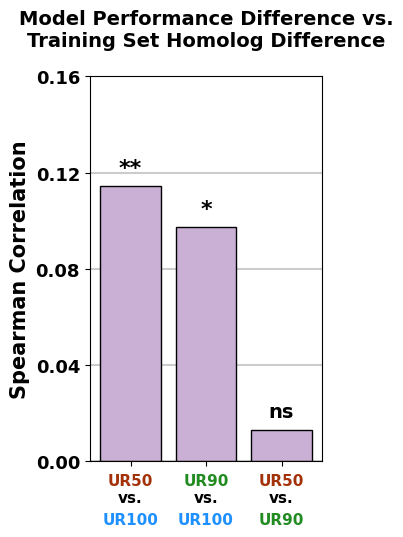

In [25]:
groups = ["UR50_UR100", "UR90_UR100", "UR50_UR90"]

fig,ax = plt.subplots(figsize = (3,5))

ax.bar(
    [0,1,2], 
    y_vals,
    color = "#cab0d4",
    edgecolor = "black",
)

str_to_color_1 = {
    "UR50" : ur_50_color,
    "UR90" : "forestgreen",
    "UR100" : ur_100_color
}

ax.set_ylabel(r"Spearman Correlation", fontsize = 15,fontweight = "bold")

ax.set_title("Model Performance Difference vs.\nTraining Set Homolog Difference\n", fontsize = 14, fontweight = "bold")
ax.set_ylim(top=0.16)

ax.set_xticklabels([""])
for i in range(0,3):
    ax.text(i, y_vals[i] + 0.005, p_val_to_stars(p_vals[i]), fontsize = 14 if p_val_to_stars(p_vals[i]) == "ns" else 16, fontweight = "bold", horizontalalignment = "center")
    
    ds1 = groups[i].split("_")[0]
    ds2 = groups[i].split("_")[1]
    
    
    ax.text(
        i,
        -0.01,
        ds1, 
        horizontalalignment = "center",
        fontsize = 11, 
        color = str_to_color_1[ds1],
        fontweight = "bold"
    )
    
    ax.text(
        i,
        -0.017,
        "vs.", 
        horizontalalignment = "center",
        fontsize = 11, 
        fontweight = "bold"
    )
    
    ax.text(
        i,
        -0.026,
        ds2, 
        horizontalalignment = "center",
        fontsize = 11, 
        color = str_to_color_1[ds2],
        fontweight = "bold"
    )
    
    
ax.set_yticks([0,0.04,0.08,0.12,0.16])
    
for i in ax.get_yticks():
    ax.axhline(y = i, color = 'black', alpha = 0.2, zorder = 0)
    
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13,fontweight = "bold")


In [26]:
df_aln = pd.read_csv(llm_review_path + "data/biolip/cat_auc_by_protein_cleaned_blast.csv.gz")
df_aln["identifier"] = df_aln["PDB ID"] + "_" + df_aln["Receptor chain"]

valid_ids = []
for k, v in id_to_num_cat_sites.items():
#     valid_ids.append(k)
    if v >= 0 and id_to_cat_site_ratio[k] >= 0.0:
        valid_ids.append(k)

len(valid_ids)

537

In [27]:
model_order_1 = [
    "esm_2_8M", 
    "esm_2_35M", 
    "esm_2_150M", 
    "esm_2_650M", 
    "esm_2", 
    "esm_2_15B", 
    "esm_1_UR50", 
    "esm_1_UR50D", 
    "esm_1_43M",
    "esm_1_85M",
    "esm_1b",
    "esm_1v",
    "esm_1_UR100",
    "protbert"
]


hom_to_performance_corr_tracker = []

data = []
for ds in ["UR50", "UR90", "UR100"]:
    lst = []
    for m in model_order_1:
        auroc_vals = summary_df_1[m].to_dict()
        x = []
        y = []
        for k, v in auroc_vals.items():
            x.append(v)
            y.append(ds_to_homs[ds][k])
            
        corr, p = scipy.stats.spearmanr(x, y)
        lst.append(corr)
        hom_to_performance_corr_tracker.append([m, "Catalytic Site Identification", ds, corr, p])
    data.append(lst)

In [28]:

# supp tables 

import copy 

display_names_a = {
    "protbert" : "ProtBERT", 
    "esm_1_43M" : "ESM-1 (43M)",
    "esm_1_85M" : "ESM-1 (85M)",
    "esm_1_UR50" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1b" : "ESM-1b",
    "esm_1v" : "ESM-1v",
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" :"ESM-2 (35M)",
    "esm_2_150M" :"ESM-2 (150M)",
    "esm_2_650M" :"ESM-2 (650M)",
    "esm_2" :"ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}

dataset_to_display_names_a = {"UR50" : "UniRef50", "UR100" : "UniRef100", "UR90" : "UniRef90"}


table_a = copy.deepcopy(summary_df_1)
table_a = table_a.rename(columns = display_names_a)

table_a_rows = []

for index, row in table_a.iterrows():
    for c in display_names_a.values():
        table_a_rows.append([index, "Catalytic Site Identification", c, row[c]])
        
table_a = pd.DataFrame(table_a_rows, columns = ["Identifier", "Task", "Model", "Performance"])
table_a.to_csv(supp_table_path + "all_model_performance_cat_site.csv", index = False)


table_b = pd.DataFrame(ds_to_homs)
table_b.index.name = "Identifier"
table_b = table_b.rename(columns = dataset_to_display_names_a)
table_b["Task"] = "Catalytic Site Identification"
table_b = table_b[["Task", "UniRef50", "UniRef90", "UniRef100"]]
table_b.to_csv(supp_table_path + "homologs_all_datasets_cat_sites.csv", index = True)



hom_to_performance_corr_tracker = pd.DataFrame(hom_to_performance_corr_tracker, columns = ["Model", "Task", "Dataset", "Spearman Correlation", "Spearman p-value"])
table_c = copy.deepcopy(hom_to_performance_corr_tracker)
table_c["Model"] = table_c["Model"].apply(lambda x : display_names_a[x])
table_c["Dataset"] = table_c["Dataset"].apply(lambda x : dataset_to_display_names_a[x])
table_c.to_csv(supp_table_path + "homologs_v_performance_all_models_all_datasets_cat_sites.csv", index = False)


table_d = []
for index, row in average_entropy_df.iterrows():
    for c in display_names_a.keys():
        disp_name = display_names_a[c]
        ent_val = row[c]
        table_d.append(["Catalytic Site Identification", index, disp_name, ent_val])

table_d = pd.DataFrame(table_d, columns = ["Task", "Identifier", "Model", "Average Site Entropy"])
table_d.to_csv(supp_table_path + "average_site_entropy_cat_sites.csv", index = False)


In [29]:
model_small = "esm_2_150M"
model_large = "esm_2_15B"

homolog_df = pd.DataFrame(ds_to_homs) 
hom_cutoff = np.median(homolog_df["UR50"].values)

print(hom_cutoff)

small_model_few = []
small_model_many = []

large_model_few = []
large_model_many = []


for k, v in homolog_df["UR50"].items():
    if k in summary_df_1.index:
        r_large = summary_df_1.loc[k][model_large]
        r_small = summary_df_1.loc[k][model_small]
        if v > hom_cutoff:
            large_model_many.append(r_large)
            small_model_many.append(r_small)
        else:
            large_model_few.append(r_large)
            small_model_few.append(r_small)
         
print(scipy.stats.mannwhitneyu(large_model_few, small_model_few, alternative = "greater"))
print(scipy.stats.mannwhitneyu(large_model_many, small_model_many, alternative = "greater"))

1277.0
MannwhitneyuResult(statistic=40579.0, pvalue=0.007353925356359551)
MannwhitneyuResult(statistic=35885.0, pvalue=0.506119199582416)


/tmp/ipykernel_125371/2766256575.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


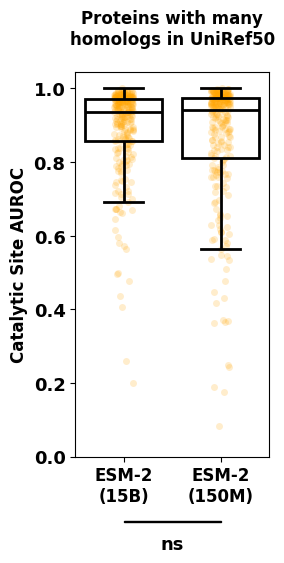

In [38]:

fig, ax = plt.subplots(figsize = (2.5, 5))


y1 = large_model_many
y2 = small_model_many


data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.2,
    color = "orange"
)

ax.set_yticks(list(np.arange(0,1.1,0.2)))
# ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold",)
ax.set_xticklabels(
    ["ESM-2\n(15B)", "ESM-2\n(150M)"],
    fontsize = 12,fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)

st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")


# ax.text(0.5, -0.29, "MWU $p = " + format_p(p) +  "$", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 13,fontweight = "bold", transform = ax.transAxes, horizontalalignment = "center")

ax.set_title("Proteins with many\nhomologs in UniRef50", fontsize = 12, fontweight = "bold", y = 1.05)
ax.set_ylabel("Catalytic Site AUROC", fontsize = 12, fontweight = "bold")

save_figure(fig, "few_homologs_cat_sites_esm_150M_15B")

In [32]:
st, p = scipy.stats.wilcoxon(y2,y1, alternative = "less")
p

0.17346006481011145

/tmp/ipykernel_125371/4138762380.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


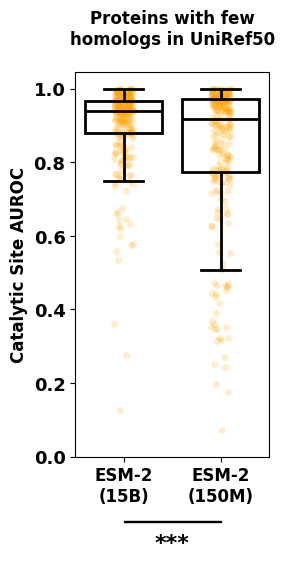

In [36]:

fig, ax = plt.subplots(figsize = (2.5, 5))
y1 = large_model_few
y2 = small_model_few




data = [y1,y2]

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)

sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.2,
    color = "orange"
)

ax.set_yticks(list(np.arange(0,1.1,0.2)))
# ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold")
ax.set_xticklabels(
    ["ESM-2\n(15B)", "ESM-2\n(150M)"],
    fontsize = 12,
    fontweight = "bold"
)

rect = mpatches.Rectangle((0.25, -0.17), 0.5, 0.003, transform = ax.transAxes, clip_on=False, linewidth=1, edgecolor=None, color = "black")
ax.add_patch(rect)

st, p = scipy.stats.wilcoxon(y2,y1,alternative = "less")


# ax.text(0.5, -0.29, "MWU $p = " + format_p(p) +  "$", fontsize = 13, transform = ax.transAxes, horizontalalignment = "center")
ax.text(0.5, -0.24, p_val_to_stars(p), fontsize = 16, transform = ax.transAxes,  fontweight = "bold", horizontalalignment = "center")

ax.set_title("Proteins with few\nhomologs in UniRef50", fontsize = 12, fontweight = "bold", y = 1.05)
ax.set_ylabel("Catalytic Site AUROC", fontsize = 12, fontweight = "bold")


save_figure(fig, "many_homologs_cat_sites_esm_150M_15B")

In [37]:
st, p = scipy.stats.wilcoxon(y2,y1, alternative = "less")
p

0.0001471338294430295

In [32]:
homolog_df = pd.DataFrame(ds_to_homs) 

small_model_few = []
small_model_many = []

large_model_few = []
large_model_many = []


for k, v in homolog_df["UR50"].items():
    if k in summary_df_1.index:
        r_large = summary_df_1.loc[k][model_large]
        r_small = summary_df_1.loc[k][model_small]
        if v > hom_cutoff:
            large_model_many.append(r_large)
            small_model_many.append(r_small)
        else:
            large_model_few.append(r_large)
            small_model_few.append(r_small)
            
print(scipy.stats.wilcoxon(large_model_few, small_model_few))
print(scipy.stats.wilcoxon(large_model_many, small_model_many))

WilcoxonResult(statistic=13425.0, pvalue=0.000294267658886059)
WilcoxonResult(statistic=16322.0, pvalue=0.3469201296202229)


In [33]:
def maximum_entropy_value(size_of_dist):
    dist = [1/size_of_dist] * size_of_dist
    ent = np.sum(list(map(lambda x : -1*(np.log2(x)*x), dist)))
    return ent

0.9055801021027128
0.9024455413543621


/tmp/ipykernel_3021047/3515341557.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3021047/3515341557.py:112: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(label, fontweight = "bold")


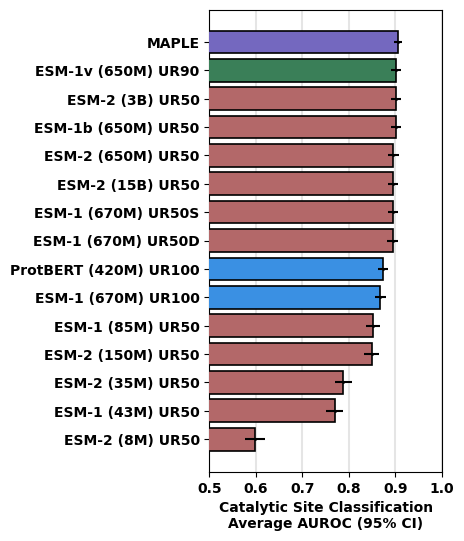

In [38]:
gamma  = 1.3
moe_results = {}
moe_choices = {}
moe_entropy = {}


for index, row in average_entropy_df.iterrows():
    if index not in valid_ids:
        continue 
    oredered_models = list(row.index)
    dist_from_optimal_entropy = np.abs(row.values - gamma)
    min_dist_index = np.argmin(dist_from_optimal_entropy)
    chosen_model = oredered_models[min_dist_index]
    chosen_model_auroc = summary_df_1.loc[index][chosen_model]
    chosen_model_entropy = row[chosen_model]
    moe_results[index] = chosen_model_auroc
    moe_choices[index] = chosen_model
    moe_entropy[index] = chosen_model_entropy
    
    

fig, ax = plt.subplots(figsize = (3,6))

model_to_label = {
    'esm_1_43M' : "ESM-1 (43M) UR50",
    'esm_1_85M': "ESM-1 (85M) UR50",
    'esm_1_UR50':"ESM-1 (670M) UR50S",
    'esm_1_UR50D':"ESM-1 (670M) UR50D",
    'esm_1_UR100':"ESM-1 (670M) UR100",
    'esm_1b':"ESM-1b (650M) UR50",
    'esm_1v':"ESM-1v (650M) UR90",
    'esm_2_150M':"ESM-2 (150M) UR50",
    'esm_2_15B':"ESM-2 (15B) UR50",
    'esm_2_35M':"ESM-2 (35M) UR50",
    'esm_2':"ESM-2 (3B) UR50",
    'esm_2_650M':"ESM-2 (650M) UR50",
    'esm_2_8M':"ESM-2 (8M) UR50",
    'protbert':"ProtBERT (420M) UR100",
    "combined" :  "MAPLE"
}

model_to_label_1 = {
    'esm_1_43M' : "ESM-1 (43M)",
    'esm_1_85M': "ESM-1 (85M)",
    'esm_1_UR50':"ESM-1 UR50S (670M)",
    'esm_1_UR50D':"ESM-1 UR50D (670M)",
    'esm_1_UR100':"ESM-1 (670M)",
    'esm_1b':"ESM-1b (650M)",
    'esm_1v':"ESM-1v (650M)",
    'esm_2_150M':"ESM-2 (150M)",
    'esm_2_15B':"ESM-2 (15B)",
    'esm_2_35M':"ESM-2 (35M)",
    'esm_2':"ESM-2 (3B)",
    'esm_2_650M':"ESM-2 (650M)",
    'esm_2_8M':"ESM-2 (8M)",
    'protbert':"ProtBERT (420M)",
    "combined" : "MAPLE"
}


data_df = []

m, ci_l, ci_u = mean_confidence_interval(list(moe_results.values()))
data_df.append(["combined", m, ci_l, ci_u])

for col in summary_df_1.columns:
    lst = summary_df_1[col].values 
    m, ci_l, ci_u = mean_confidence_interval(lst)
    data_df.append([col, m, ci_l, ci_u])
    
data_df = pd.DataFrame(data_df, columns = ["model", "mean", "ci_l", "ci_u"])

data_df = data_df.sort_values(by = "mean", ascending = False)

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in data_df.iterrows():
    res.append(row["mean"])
    
    label.append(model_to_label[row["model"]])
    y.append(c)
    err_vals.append(row["mean"] - row["ci_l"])
    if row["model"] == "combined":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color[row["model"]]
        if color == "#A3320B":
            color = "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6,0.7,0.8,0.9,1.0])
ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold")
ax.set_xlim(left = 0.5, right = 1)

ax.scatter(res, y, color = "black", s = 1)
ax.errorbar(res, y, xerr = err_vals, fmt = ".", zorder = 1000, markersize = 1, color = "black")

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)


ax.set_xlabel("Catalytic Site Classification\nAverage AUROC (95% CI)", fontweight = "bold")
ax.set_yticklabels(label, fontweight = "bold")

print(np.mean(list(moe_results.values())))
print(np.mean(summary_df_1["esm_1v"].values))



In [60]:
combined_score = res[0]
highest_alt = res[1]

pct_increase = (combined_score - highest_alt) / highest_alt

print("pct increase", pct_increase)

z_val = np.std(res[1:])

print(z_val)

print("z increase", (combined_score - highest_alt) / z_val)

pct increase 0.003473407097392794
0.08050163477724691
z increase 0.038937852094858075


In [61]:
!ls ../../isabel/correct_positional_entropies/

alignment_entropy_values = {}

for dataset in ["UR50", "UR90", "UR100"]:
    with open(f"../../isabel/correct_positional_entropies/id_to_pos_entropy_alignment_{dataset}.json", "r") as f:
        data = json.load(f)
        alignment_entropy_values[dataset] = data
    f.close()

id_to_pos_entropy_alignment_UR100.json	id_to_pos_entropy_alignment_UR90.json
id_to_pos_entropy_alignment_UR50.json


In [62]:
auroc_res_alignments = {d : {} for d in  ["UR50", "UR90", "UR100"]}

for index, row in biolip_cleaned.iterrows():
    seq = [*row["Receptor_sequence"]]
    ident = row["identifier"]
    cat_sites = row["Catalytic_site_residues_numbered"].split(" ")
    cat_site_ref = []
    cat_site_pos = []
    for cs in cat_sites:
        ref = cs[0]
        pos = int(cs[1:])
        cat_site_ref.append(ref)
        cat_site_pos.append(pos)
        assert seq[pos - 1] == ref
    
    labels = np.zeros(len(seq))
    for cs_pos in cat_site_pos:
        labels[cs_pos - 1] = 1
        
    for d in ["UR50", "UR90", "UR100"]:
        
        raw_values = alignment_entropy_values[d][ident]
        int_cast_values = {}
        for k, v in raw_values.items():
            int_cast_values[int(k)] = v
 
        predictions = list(sort_dict_by_key(int_cast_values).values())
        # order of entropy - more negative needs to correspond to more likely catalytic site
        # need to make 'positive' class 0 to line up correctly 
        fpr, tpr, thresholds = metrics.roc_curve(labels, predictions, pos_label=0)
        auroc = metrics.auc(fpr, tpr)
        auroc_res_alignments[d][ident] = auroc
        
summary_df_alignments = pd.DataFrame(auroc_res_alignments)

537
MannwhitneyuResult(statistic=137858.5, pvalue=0.21330275628639284)
MannwhitneyuResult(statistic=135331.0, pvalue=0.08154023897069183)
MannwhitneyuResult(statistic=166503.0, pvalue=1.1280903916648817e-05)


/tmp/ipykernel_3021047/1645747698.py:82: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((0, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
/tmp/ipykernel_3021047/1645747698.py:88: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((2, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
/tmp/ipykernel_3021047/1645747698.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.Rectangle((4, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')


Text(0.5, 1.0, 'BioLiP2 Catalytic Site Proteins\n')

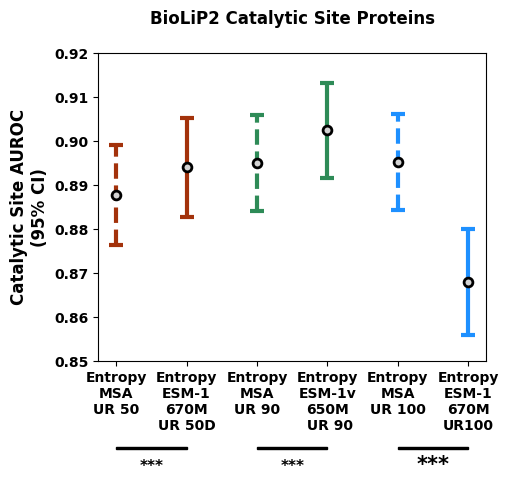

In [64]:

data = [
    summary_df_alignments["UR50"].values,
    summary_df_1["esm_1_UR50D"].values,
    summary_df_alignments["UR90"].values,
    summary_df_1["esm_1v"].values,
    summary_df_alignments["UR100"].values,
    summary_df_1["esm_1_UR100"].values,
]

print(len(data[0]))

x = []
mean_vals = []
error_vals = []

for i , d_lst in enumerate(data):
    mci = mean_confidence_interval(d_lst)
    x.append(i)
    mean_vals.append(mci[0])
    error_vals.append([mci[0] - mci[1], mci[2] - mci[0]])
    

fig, ax = plt.subplots(figsize = (5,4))

groups = [[0,2], [2,4], [4,6]]
c_list = [ur_50_color, ur_90_color, ur_100_color]
for c, g in zip(c_list,groups):
    
    e1 = ax.errorbar(
        x[g[0]:g[1]], 
        mean_vals[g[0]:g[1]], 
        yerr = np.transpose(error_vals[g[0]:g[1]]), 
        color = c, 
        fmt = ".",
        capsize = 5,
        linewidth = 3,
        zorder = 1
    )
    
    
    e1[-1][0].set_linestyle(['--','-']*3)
    caps = e1[1]
    
    for cap in caps:
        cap.set_markeredgewidth(3)


    ax.scatter(
        x[g[0]:g[1]], 
        mean_vals[g[0]:g[1]], 
        color = "lightgray", 
        edgecolor = "black",
        linewidth=2,
        s = 40,
        zorder = 100
    )
    
    
    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Entropy\nMSA\nUR 50",
            "Entropy\nESM-1\n670M\nUR 50D",
            "Entropy\nMSA\nUR 90",
            "Entropy\nESM-1v\n650M\n UR 90",
            "Entropy\nMSA\nUR 100",
            "Entropy\nESM-1\n670M\nUR100",
            
        ],
        fontweight = "bold"
    )
    

print(scipy.stats.mannwhitneyu(summary_df_alignments["UR50"].values,summary_df_1["esm_1_UR50D"].values))
print(scipy.stats.mannwhitneyu(summary_df_alignments["UR90"].values,summary_df_1["esm_1v"].values))
print(scipy.stats.mannwhitneyu(summary_df_alignments["UR100"].values,summary_df_1["esm_1_UR100"].values))

ax.set_ylabel("Catalytic Site AUROC\n(95% CI)", fontsize = 12, fontweight = "bold")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

rect = mpatches.Rectangle((0, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )

st, p1 = scipy.stats.wilcoxon(summary_df_alignments["UR50"].values, summary_df_1["esm_1_UR50D"].values)
ax.text(0.5, 0.825, p_val_to_stars(p1), fontsize = 11, horizontalalignment = "center", fontweight = "bold")

rect = mpatches.Rectangle((2, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )

st, p1 = scipy.stats.wilcoxon(summary_df_alignments["UR90"].values, summary_df_1["esm_1v"].values)
ax.text(2.5, 0.825, p_val_to_stars(p1), fontsize = 11, horizontalalignment = "center", fontweight = "bold")

rect = mpatches.Rectangle((4, 0.83), 1, 0.0005,  clip_on=False, linewidth=1, edgecolor='black', color = 'black')
ax.add_patch(rect, )

st, p1 = scipy.stats.wilcoxon(summary_df_alignments["UR100"].values, summary_df_1["esm_1_UR100"].values)
ax.text(4.5, 0.825, p_val_to_stars(p1), fontsize = 15, horizontalalignment = "center", fontweight = "bold")

ax.set_title("BioLiP2 Catalytic Site Proteins\n", fontsize = 12, fontweight = "bold")

In [44]:
d1 = summary_df_1["esm_1_UR50D"].to_dict()
d2 = summary_df_alignments["UR50"].to_dict()

x1,x2 = [],[]
for k,v in d1.items():
    x1.append(v)
    x2.append(d2[k])
    
print(scipy.stats.wilcoxon(x1,x2))


d1 = summary_df_1["esm_1v"].to_dict()
d2 = summary_df_alignments["UR90"].to_dict()

x1,x2 = [],[]
for k,v in d1.items():
    x1.append(v)
    x2.append(d2[k])
    
print(scipy.stats.wilcoxon(x1,x2))


d1 = summary_df_1["esm_1_UR100"].to_dict()
d2 = summary_df_alignments["UR100"].to_dict()

x1,x2 = [],[]
for k,v in d1.items():
    x1.append(v)
    x2.append(d2[k])
    
print(scipy.stats.wilcoxon(x1,x2))

WilcoxonResult(statistic=55935.0, pvalue=1.8793579343040356e-05)
WilcoxonResult(statistic=54843.0, pvalue=2.4833339754490826e-06)
WilcoxonResult(statistic=55655.5, pvalue=1.750992108463518e-05)


In [45]:
d1_model = summary_df_1["esm_1_UR50D"].to_dict()
d1_aln = summary_df_alignments["UR50"].to_dict()
x1 = []
x2 = []
for k, v in d1_model.items():
    x1.append(v)
    x2.append(d1_aln[k])

scipy.stats.ks_2samp(x1,x2, alternative = "greater")

KstestResult(statistic=0.0223463687150838, pvalue=0.7649619695348401)

In [46]:
display_names_a = {
    "protbert" : "ProtBERT", 
    "esm_1_43M" : "ESM-1 (43M)",
    "esm_1_85M" : "ESM-1 (85M)",
    "esm_1_UR50" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1b" : "ESM-1b",
    "esm_1v" : "ESM-1v",
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" :"ESM-2 (35M)",
    "esm_2_150M" :"ESM-2 (150M)",
    "esm_2_650M" :"ESM-2 (650M)",
    "esm_2" :"ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)"
}

dataset_to_display_names_a = {"UR50" : "UniRef50", "UR100" : "UniRef100", "UR90" : "UniRef90"}


table_e = summary_df_alignments.rename(columns = dataset_to_display_names_a)
table_e["Task"] = "Catalytic Site Identification"
table_e = table_e[["Task", "UniRef50", "UniRef90", "UniRef100"]]
table_e.index.name = "Identifier"
table_e.to_csv(supp_table_path + "aln_scores_all_datasets_cat_sites.csv", index = True)


table_f = []
for k, v in moe_results.items():
    table_f.append([k, "Catalytic Site Identification", v, moe_choices[k], moe_entropy[k]])
    
table_f = pd.DataFrame(table_f, columns = ["Identifier", "Task", "Optimal Model Performance", "Optimal Model Choice", "Optimal Model Average Site Entropy"])
table_f["Optimal Model Choice"] = table_f["Optimal Model Choice"].apply(lambda x : display_names_a[x])
table_f.to_csv(supp_table_path + "entropy_optimal_model_choices_cat_sites.csv", index = False)

In [48]:
alignment_entropy_values = {}

for dataset in ["UR50", "UR90", "UR100"]:
    with open(f"../../isabel/correct_positional_entropies/id_to_pos_entropy_alignment_{dataset}.json", "r") as f:
        data = json.load(f)
        alignment_entropy_values[dataset] = data
    f.close()

/tmp/ipykernel_3021047/1625394314.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


(0.0, 4.322)

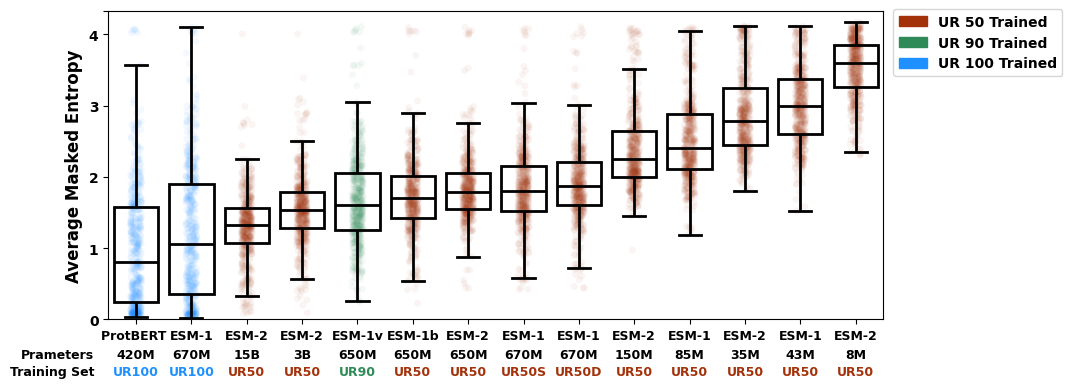

In [58]:
models = set(model_to_base_string.keys())


entropy_df = average_entropy_df

# for m, gene_vals in model_to_protein_site_entropy.items():
#     model_results = {}
#     for gene_id, gene_position_dict in gene_vals.items():
#         gene_mean_entropy = np.mean(list(gene_position_dict.values()))
#         model_results[gene_id] = gene_mean_entropy
        
#     entropy_df[m] = model_results


# moe_results = {}
# entropy_df = pd.DataFrame(entropy_df)
entropy_df = entropy_df.loc[entropy_df.index!="DAXX"]


m_to_median_entropy = {m : np.median(entropy_df[m].values) for m in entropy_df.columns}
m_to_median_entropy = sort_dict_by_value(m_to_median_entropy)


x = []
data = []
x_ticklabels = []

my_pal = []

i = 0
for m, v in m_to_median_entropy.items():
   
    x.append(i)
    x_ticklabels.append(model_to_base_string[m])
    data.append(entropy_df[m].values)
    my_pal.append(model_to_color[m])
    i += 1
    
fig, ax = plt.subplots(figsize = (10,4))

sns.boxplot(
    data, 
    color = "white", 
    boxprops=dict(linewidth=2, facecolor=(0, 0, 0, 0), edgecolor='black', zorder = 100),
    medianprops=dict(linewidth=2, color='black', zorder = 100),
    whiskerprops=dict(linewidth=2, color='black', zorder = 100),
    capprops = dict(linewidth=2, color='black', zorder = 100),
    showfliers = False
)


sns.stripplot(
    data, 
    zorder = 1, 
    alpha = 0.05,
    color = "lightsteelblue",
    palette = my_pal
)

ax.set_ylabel("Average Masked Entropy", fontsize = 12,fontweight = "bold")
ax.set_xticks(x)
ax.set_xticklabels(
    x_ticklabels, 
    fontsize = 9,
    fontweight = "bold"
)
x_i = 0
for i, k in enumerate(m_to_median_entropy.keys()):
    if k == "protbert_bfd":
        continue 
    ax.text(x_i, -0.55, model_to_params_string[k], fontsize = 9, horizontalalignment = "center",fontweight = "bold")
    ax.text(x_i, -0.78,model_to_dataset_string[k].replace("-",""), fontsize = 9 , horizontalalignment = "center", color=model_to_color[k],fontweight = "bold" )
    x_i += 1

ax.text(-0.75, -0.55, "Prameters", fontsize = 9, horizontalalignment = "right",fontweight = "bold")
ax.text(-0.75, -0.78, "Training Set", fontsize = 9, horizontalalignment = "right",fontweight = "bold")

ent_ticks= [0,1,2,3,4,4.322]
ent_labels = ["0", "1","2","3","4", ""]
ax.set_yticks(ent_ticks)
ax.set_yticklabels(ent_labels,fontweight = "bold")

red_patch = mpatches.Patch(color=ur_50_color, label='UR 50 Trained')
blue_patch = mpatches.Patch(color=ur_100_color, label='UR 100 Trained')
green_patch = mpatches.Patch(color=ur_90_color, label='UR 90 Trained')
ax.legend(handles=[red_patch,green_patch,blue_patch,], bbox_to_anchor = (0.74,0.53,0.5,0.5), prop = {"weight" : "bold"})

ax.set_ylim(bottom = 0, top = 4.322)



In [51]:
average_entropy_df

,esm_1_43M,esm_1_85M,esm_1_UR50,esm_1_UR50D,esm_1_UR100,esm_1b,esm_1v,esm_2_150M,esm_2_15B,esm_2_35M,esm_2,esm_2_650M,esm_2_8M,protbert
7pcy_A,3.286208,3.115315,2.361153,2.464054,2.730706,1.956024,1.956065,2.600143,0.779662,2.906842,1.040581,1.616328,3.284771,2.226975
1bxo_A,3.082020,2.363561,1.428396,1.419061,1.703733,1.301806,1.869113,1.921231,1.125848,2.572257,1.214626,1.373633,3.366876,1.421804
3eng_A,4.054466,4.002283,1.701797,1.656165,2.283511,1.508508,1.889803,1.999794,1.110694,3.919411,1.194362,1.424783,4.104386,1.417352
1isv_B,2.681906,1.932735,0.963680,0.998579,0.510476,0.889263,0.697531,1.797133,0.518612,2.274631,0.739015,1.214200,3.115648,0.422652
1pla_A,3.002783,2.829403,1.980780,2.163271,2.301244,1.716194,1.745147,2.346853,0.741258,2.739530,1.086733,1.464336,3.112316,1.548658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2qes_A,4.085145,4.086485,4.058009,4.017269,4.064996,4.051781,4.078338,4.041318,1.803693,4.089614,3.007103,4.044791,4.065818,4.057462
1elt_A,2.482631,2.242556,1.265815,1.390341,1.250726,1.192825,1.883403,2.101946,1.098163,2.412633,1.219926,1.433384,2.791659,1.081932
1zbk_A,2.617033,2.135159,1.730203,1.877412,1.221542,1.601232,2.159127,2.091530,1.603197,2.395507,1.714357,1.794601,3.291663,0.699348
5tj9_C,3.724726,2.847042,1.972860,2.012195,2.161552,1.918334,2.159419,3.633035,2.245731,3.816457,2.621164,2.745802,3.748354,1.674754
